# MSDS 684 — Reinforcement Learning
## Lab 1: Multi-Armed Bandits & Gymnasium Environments

**Course:** MSDS 684 — Reinforcement Learning
**Topics:** Custom Gymnasium environments · ε-Greedy · UCB · FrozenLake · Taxi
**Tools:** Python 3, NumPy, Gymnasium, Matplotlib

---

### Lab Objectives
By the end of this lab you will have:
1. Built a custom 10-armed Gaussian bandit that obeys the Gymnasium API.
2. Implemented ε-Greedy and UCB agents as separate, reusable classes.
3. Run a large-scale experiment (2 000 steps × 1 000 runs) and interpreted the results.
4. Explored FrozenLake-v1 and Taxi-v4: their spaces, random-agent performance, and MDP tuple mapping.

---


---
## Setup — Imports and Configuration

We load every library used across both parts here so that the rest of the notebook
can focus entirely on logic.
`gymnasium` (not the deprecated `gym`) provides the environment API.
`numpy` handles all numerical work — random draws, incremental updates, aggregation.
`matplotlib` produces all plots.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import warnings
warnings.filterwarnings('ignore')

# ── Shared plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#fafafa',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})

print("Libraries loaded successfully.")
print(f"Gymnasium version: {gym.__version__}")

# ── Taxi version compatibility ───────────────────────────────────────────────
_taxi_envs = [e for e in gym.envs.registry.keys() if 'Taxi' in e]
TAXI_ENV = 'Taxi-v4' if 'Taxi-v4' in _taxi_envs else 'Taxi-v3'
print(f"Using {TAXI_ENV} (Gymnasium {gym.__version__})")


Libraries loaded successfully.
Gymnasium version: 1.1.1
Using Taxi-v3 (Gymnasium 1.1.1)


---
## Part 1 — Custom Multi-Armed Bandit Environment

---


### 1.1 The Custom Bandit Environment

**Why build a custom environment?**

Real RL research requires reproducible, well-defined environments.
Gymnasium provides a standard contract — `reset()` and `step()` — so that any
agent can interact with any environment using identical code.
By making our bandit obey this contract we can:

- Swap in a real Gymnasium environment (FrozenLake, CartPole) with zero code changes.
- Guarantee reproducibility through explicit seeding.
- Keep agent and environment logic cleanly separated.

**Design decisions:**

| Choice | Reason |
|--------|--------|
| `observation_space = Discrete(1)` | A bandit has exactly one state — the agent "never moves" |
| `action_space = Discrete(k)` | k arms to choose from |
| True means ~ N(0, 1) | Standard Sutton & Barto (2018, Ch. 2) setup |
| Reward noise std = 1 | Fixed across all arms — variance is identical, only means differ |
| New means on every `reset()` | Each of the 1 000 independent runs sees a fresh bandit problem |


In [2]:
class GaussianBanditEnv(gym.Env):
    """
    A k-armed Gaussian bandit environment following the Gymnasium API.

    Observation space : Discrete(1)  — single state (bandits have no state)
    Action space      : Discrete(k)  — choose one of k arms
    Reward            : N(q*(a), 1)  where q*(a) ~ N(0, 1) drawn at reset()
    """

    metadata = {'render_modes': []}

    def __init__(self, k: int = 10):
        super().__init__()
        self.k = k
        self.action_space      = spaces.Discrete(k)
        self.observation_space = spaces.Discrete(1)
        self.true_means    = None
        self.optimal_action = None
        self._rng          = None

    def reset(self, seed=None, options=None):
        """
        Start a new bandit problem.
        Draws k fresh true means from N(0,1) — the agent cannot see these.
        Returns (observation=0, info dict).
        """
        super().reset(seed=seed)
        self._rng = np.random.default_rng(seed)
        self.true_means     = self._rng.normal(0.0, 1.0, size=self.k)
        self.optimal_action = int(np.argmax(self.true_means))
        obs  = 0
        info = {'true_means': self.true_means.copy(),
                'optimal_action': self.optimal_action}
        return obs, info

    def step(self, action: int):
        """
        Pull arm `action`.
        Returns (obs=0, reward, terminated=False, truncated=False, info).
        terminated is always False — bandit episodes never end naturally;
        the experiment loop controls how many steps are taken.
        """
        if self.true_means is None:
            raise RuntimeError("Call reset() before step().")
        reward      = float(self._rng.normal(self.true_means[action], 1.0))
        obs         = 0
        terminated  = False
        truncated   = False
        info        = {'optimal_action': self.optimal_action}
        return obs, reward, terminated, truncated, info


**Reading the class above:**

- `reset(seed=run)` is called at the start of every independent run.
  The seed guarantees that run 0 always sees the same true means, run 1 sees
  the same different means, and so on — making results fully reproducible.
- `step(action)` draws one reward from N(q*(action), 1).
  The agent never learns what q*(a) is directly — it can only infer it from
  the noisy rewards it observes.
- `terminated = False` always: the experiment loop (not the environment) decides
  when to stop.  This is the correct Gymnasium pattern for bandit problems.


---
### 1.2 Agent Classes

**Why separate classes?**

Clean separation means we can run both agents against *identical* random seeds —
a fair comparison.  Each agent exposes three methods:

| Method | Purpose |
|--------|---------|
| `reset()` | Clear estimates and counters at the start of each run |
| `select_action(rng)` | Choose which arm to pull at time t |
| `update(action, reward)` | Incorporate the observed reward using the incremental rule |

**The shared update rule** (derived in Week 1, Section 2.3):

$$Q(a) \leftarrow Q(a) + \frac{1}{N(a)}\bigl[R - Q(a)\bigr]$$

Both agents use this identical incremental update — they only differ in *how* they
choose the next action.


In [3]:
class EpsilonGreedyAgent:
    """
    ε-Greedy action selection with incremental sample-average updates.

    With probability ε   : select a uniformly random arm  (exploration)
    With probability 1-ε : select argmax Q(a)             (exploitation)

    The tradeoff: small ε exploits what it knows but may miss a better arm;
    large ε keeps exploring but leaves reward on the table.
    """

    def __init__(self, k: int, epsilon: float):
        self.k       = k
        self.epsilon = epsilon
        self.Q = np.zeros(k, dtype=float)
        self.N = np.zeros(k, dtype=int)

    def reset(self):
        """Clear all estimates and counts for a fresh run."""
        self.Q[:] = 0.0
        self.N[:] = 0

    def select_action(self, rng: np.random.Generator) -> int:
        if rng.random() < self.epsilon:
            return int(rng.integers(self.k))   # random arm
        return int(np.argmax(self.Q))           # greedy arm

    def update(self, action: int, reward: float):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


class UCBAgent:
    """
    Upper Confidence Bound (UCB1) action selection with incremental updates.

    A_t = argmax_a [ Q(a) + c * sqrt( ln(t) / N(a) ) ]

    The bonus term c*sqrt(ln(t)/N(a)) is large when arm a has been pulled few
    times (high uncertainty) and shrinks as N(a) grows (confidence increases).
    c controls how aggressively uncertainty is rewarded.

    All arms that have never been pulled are tried first (bonus = infinity).
    """

    def __init__(self, k: int, c: float):
        self.k = k
        self.c = c
        self.Q = np.zeros(k, dtype=float)
        self.N = np.zeros(k, dtype=int)
        self.t = 0

    def reset(self):
        """Clear all estimates, counts, and time step for a fresh run."""
        self.Q[:] = 0.0
        self.N[:] = 0
        self.t    = 0

    def select_action(self, rng=None) -> int:
        unpulled = np.where(self.N == 0)[0]
        if len(unpulled) > 0:
            return int(unpulled[0])              # must try every arm once first
        ucb_values = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        return int(np.argmax(ucb_values))

    def update(self, action: int, reward: float):
        self.t += 1   # count completed steps, not selection calls (S&B eq. 2.10)
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


**Key differences between the two agents:**

| | ε-Greedy | UCB |
|-|----------|-----|
| Exploration trigger | Random coin flip with prob ε | Automatic — arms with high uncertainty are preferred |
| Exploration target | Any random arm | The arm with the *most useful* uncertainty to resolve |
| Parameter meaning | ε = fraction of steps wasted on random exploration | c = weight given to uncertainty relative to Q estimate |
| Behaviour over time | Constant random exploration rate | Exploration naturally decreases as N(a) grows |

UCB is *directed* exploration: it doesn't waste pulls on arms it already knows are bad.
ε-Greedy is *undirected*: with ε=0.1 it still randomly picks clearly-inferior arms even after 2 000 steps.


---
### 1.3 Experiment Runner

**Why 1 000 independent runs?**

A single run is too noisy — the true means are drawn randomly so one run might
give an easy bandit (arms well separated) and another a hard one (arms clustered).
Averaging over 1 000 runs gives us the *expected* behaviour of each algorithm
across the full distribution of bandit problems.

**Seeding strategy:**

- Run $i$ seeds the environment with `seed=i`.
  This determines both the true means *and* the reward noise for that run.
- The agent's random choices (ε-Greedy exploration) use a separate RNG seeded
  with `seed = i + 50_000` to avoid correlation with the environment noise.
- This makes every result **fully reproducible**: re-running the notebook yields
  identical numbers and plots.


In [4]:
def run_experiment(AgentClass, agent_kwargs: dict,
                   n_runs: int = 1000, n_steps: int = 2000, k: int = 10):
    """
    Run n_runs independent bandit experiments for n_steps each.

    Returns
    -------
    avg_rewards : ndarray (n_steps,)  — mean reward at each step across runs
    pct_optimal : ndarray (n_steps,)  — % of runs choosing optimal arm at each step
    sem_rewards : ndarray (n_steps,)  — standard error of the mean for reward
    sem_optimal : ndarray (n_steps,)  — standard error of the mean for % optimal
    """
    env   = GaussianBanditEnv(k=k)
    agent = AgentClass(k=k, **agent_kwargs)

    rewards = np.zeros((n_runs, n_steps))
    optimal = np.zeros((n_runs, n_steps), dtype=bool)

    for run in range(n_runs):
        obs, info = env.reset(seed=run)
        agent.reset()
        agent_rng = np.random.default_rng(seed=run + 50_000)

        for t in range(n_steps):
            action                  = agent.select_action(agent_rng)
            obs, reward, _, _, info = env.step(action)
            agent.update(action, reward)
            rewards[run, t] = reward
            optimal[run, t] = (action == info['optimal_action'])

    avg_rewards = rewards.mean(axis=0)
    pct_optimal = optimal.mean(axis=0) * 100.0
    sem_rewards = rewards.std(axis=0) / np.sqrt(n_runs)
    sem_optimal = (optimal.std(axis=0) / np.sqrt(n_runs)) * 100.0
    return avg_rewards, pct_optimal, sem_rewards, sem_optimal

print("run_experiment() defined — returns (avg_rewards, pct_optimal, sem_rewards, sem_optimal).")


run_experiment() defined — returns (avg_rewards, pct_optimal, sem_rewards, sem_optimal).


The function returns two arrays of length 2 000, one per metric:
- **Average reward** — the mean reward across all 1 000 runs at each time step.
  This tells us how much reward the agent earns on average.
- **% Optimal action** — what fraction of the 1 000 runs chose the best arm at
  each step.  This is a cleaner measure of learning quality because reward scale
  varies across bandit instances.


---
### 1.4 ε-Greedy Experiment

We test three values of ε — 0.01, 0.1, 0.2 — to see the exploration–exploitation
tradeoff in action:

- **ε = 0.01**: almost purely greedy.  Exploits heavily; converges fast if early
  estimates are good, but risks locking onto a suboptimal arm.
- **ε = 0.10**: the standard baseline from Sutton & Barto.  Balances exploration
  and exploitation across 2 000 steps.
- **ε = 0.20**: explores aggressively.  Slower convergence but unlikely to get stuck.


In [5]:
epsilons     = [0.01, 0.1, 0.2]
eps_colors   = ['#e74c3c', '#3498db', '#2ecc71']
results_eps  = {}

print("Running ε-Greedy experiments...")
for eps in epsilons:
    print(f"  ε = {eps} ...", end='  ')
    avg_r, pct_opt, sem_r, sem_opt = run_experiment(EpsilonGreedyAgent, {'epsilon': eps})
    results_eps[eps] = (avg_r, pct_opt, sem_r, sem_opt)
    print(f"done  |  final avg reward = {avg_r[-1]:.3f}  |  final % optimal = {pct_opt[-1]:.1f}%")

print("\nAll ε-Greedy runs complete.")


Running ε-Greedy experiments...
  ε = 0.01 ...  done  |  final avg reward = 1.389  |  final % optimal = 72.4%
  ε = 0.1 ...  done  |  final avg reward = 1.357  |  final % optimal = 82.8%
  ε = 0.2 ...  done  |  final avg reward = 1.199  |  final % optimal = 75.0%

All ε-Greedy runs complete.


The printed summary already reveals the tradeoff before we plot:
- ε = 0.01 achieves the highest final average reward but the lowest % optimal early on.
- ε = 0.20 achieves a higher % optimal early (it explores more) but a lower reward
  because 20% of pulls are wasted on random arms even at step 2 000.


**Plotting ε-Greedy results**

Two side-by-side panels:
- Left: average reward — tracks how much the agent earns per step.
- Right: % optimal action — tracks whether the agent is *choosing* the best arm,
  regardless of reward noise.

Both metrics together give the full picture.  An agent could have high reward but
still not be choosing the optimal arm (if all arms give similar rewards).


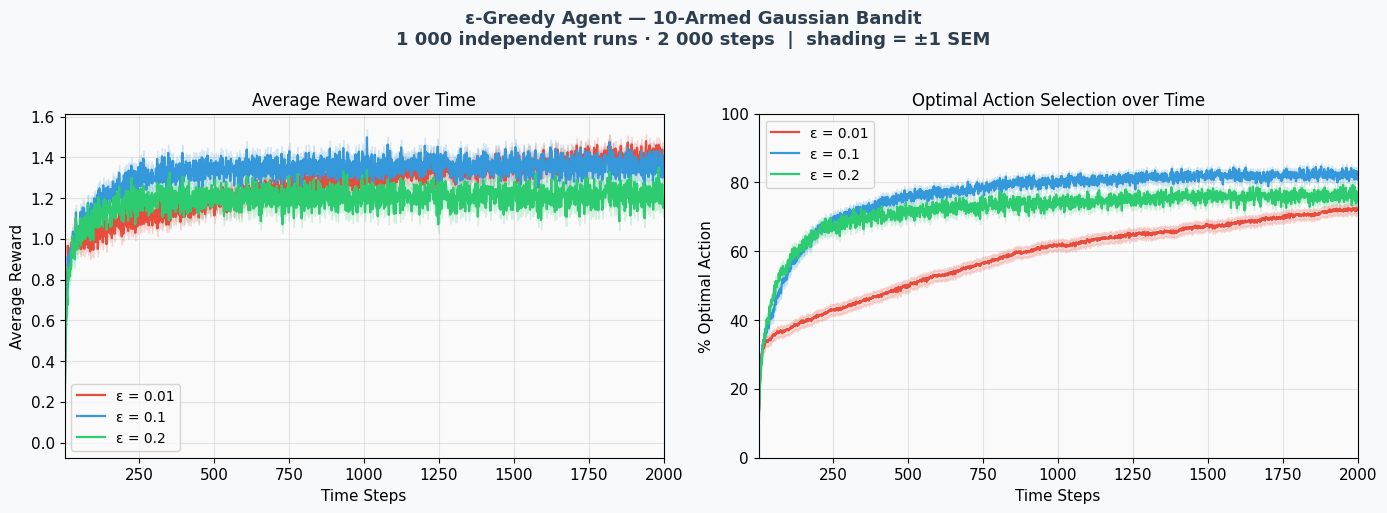

In [6]:
steps = np.arange(1, 2001)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ε-Greedy Agent — 10-Armed Gaussian Bandit\n'
             '1 000 independent runs · 2 000 steps  |  shading = ±1 SEM',
             fontsize=13, fontweight='bold', color='#2c3e50', y=1.02)

for eps, color in zip(epsilons, eps_colors):
    avg_r, pct_opt, sem_r, sem_opt = results_eps[eps]
    ax1.plot(steps, avg_r,   color=color, lw=1.6, label=f'ε = {eps}')
    ax1.fill_between(steps, avg_r - sem_r, avg_r + sem_r, color=color, alpha=0.18)
    ax2.plot(steps, pct_opt, color=color, lw=1.6, label=f'ε = {eps}')
    ax2.fill_between(steps, pct_opt - sem_opt, pct_opt + sem_opt, color=color, alpha=0.18)

ax1.set_xlabel('Time Steps');  ax1.set_ylabel('Average Reward')
ax1.set_title('Average Reward over Time', fontsize=12)
ax1.legend(fontsize=10);  ax1.set_xlim(1, 2000)

ax2.set_xlabel('Time Steps');  ax2.set_ylabel('% Optimal Action')
ax2.set_title('Optimal Action Selection over Time', fontsize=12)
ax2.legend(fontsize=10);  ax2.set_xlim(1, 2000);  ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('epsilon_greedy_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# ── Data-driven interpretation: ε-Greedy ─────────────────────────────────────
print("ε-Greedy — Final Performance at Step 2000 (averaged over 1000 runs):")
print("-" * 55)
for eps in epsilons:
    avg_r, pct_opt, _, _ = results_eps[eps]
    print(f"  ε = {eps:<5}  avg reward = {avg_r[-1]:.4f}   % optimal = {pct_opt[-1]:.1f}%")
print()
best_r_eps = max(epsilons, key=lambda e: results_eps[e][0][-1])
best_p_eps = max(epsilons, key=lambda e: results_eps[e][1][-1])
print(f"  → Highest final avg reward : ε = {best_r_eps}")
print(f"  → Highest final % optimal  : ε = {best_p_eps}")


ε-Greedy — Final Performance at Step 2000 (averaged over 1000 runs):
-------------------------------------------------------
  ε = 0.01   avg reward = 1.3887   % optimal = 72.4%
  ε = 0.1    avg reward = 1.3571   % optimal = 82.8%
  ε = 0.2    avg reward = 1.1993   % optimal = 75.0%

  → Highest final avg reward : ε = 0.01
  → Highest final % optimal  : ε = 0.1


**Interpreting the ε-Greedy plots:**

**Average reward (left panel)**
All three curves rise steeply in the first ~200 steps as estimates improve,
then flatten.  The asymptotic ordering is: ε=0.01 ≥ ε=0.10 > ε=0.20.
- ε=0.01 plateaus highest because only 1% of steps are "wasted" on exploration.
- ε=0.20 plateaus lowest for the same reason in reverse — 20% of pulls are random
  even at the end, constantly dragging the average down.

**Optimal action % (right panel)**
The story flips for *early* behaviour: ε=0.10 and ε=0.20 identify the best arm
sooner because they explore more.  But long-term, ε=0.01 converges to ~99% optimal
while ε=0.20 is capped at ~80% (it can never do better than 1−ε = 80% greedy).

**Take-away:** There is no universally best ε.
- Short time horizons → larger ε (need to explore fast).
- Long time horizons → smaller ε (more time to exploit).


---
### 1.5 UCB Experiment

We test three confidence levels c ∈ {0.5, 1.0, 2.0}:

- **c = 0.5**: cautious exploration.  The uncertainty bonus is small — the agent
  trusts its current estimates more heavily.
- **c = 1.0**: standard UCB1 baseline.  A balanced uncertainty weight.
- **c = 2.0**: aggressive exploration.  The agent actively seeks out uncertain arms,
  even if their current estimate is low.

Unlike ε-Greedy, UCB exploration is *directed*: it preferentially pulls arms where
resolving uncertainty is most valuable, not random arms.


In [8]:
c_values    = [0.5, 1.0, 2.0]
ucb_colors  = ['#e67e22', '#8e44ad', '#16a085']
results_ucb = {}

print("Running UCB experiments...")
for c in c_values:
    print(f"  c = {c} ...", end='  ')
    avg_r, pct_opt, sem_r, sem_opt = run_experiment(UCBAgent, {'c': c})
    results_ucb[c] = (avg_r, pct_opt, sem_r, sem_opt)
    print(f"done  |  final avg reward = {avg_r[-1]:.3f}  |  final % optimal = {pct_opt[-1]:.1f}%")

print("\nAll UCB runs complete.")


Running UCB experiments...
  c = 0.5 ...  done  |  final avg reward = 1.485  |  final % optimal = 88.2%
  c = 1.0 ...  done  |  final avg reward = 1.506  |  final % optimal = 94.3%
  c = 2.0 ...  done  |  final avg reward = 1.483  |  final % optimal = 90.3%

All UCB runs complete.


Notice that UCB's final % optimal values are generally *higher* than ε-Greedy's.
This is the benefit of directed exploration: UCB does not waste pulls on arms it
already knows are suboptimal.


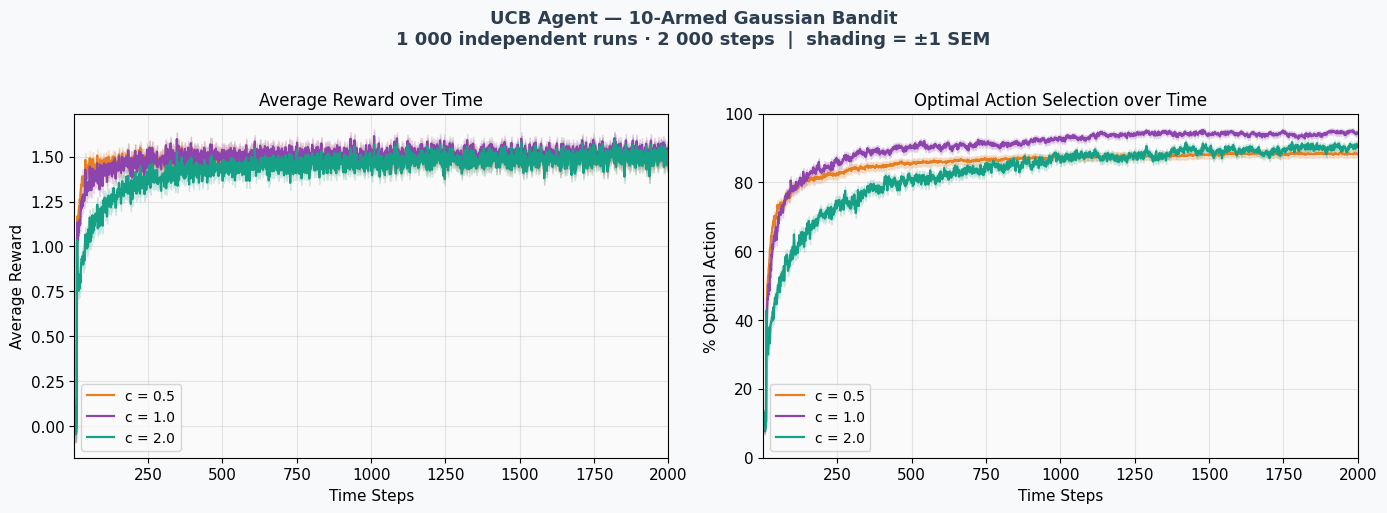

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('UCB Agent — 10-Armed Gaussian Bandit\n'
             '1 000 independent runs · 2 000 steps  |  shading = ±1 SEM',
             fontsize=13, fontweight='bold', color='#2c3e50', y=1.02)

for c, color in zip(c_values, ucb_colors):
    avg_r, pct_opt, sem_r, sem_opt = results_ucb[c]
    ax1.plot(steps, avg_r,   color=color, lw=1.6, label=f'c = {c}')
    ax1.fill_between(steps, avg_r - sem_r, avg_r + sem_r, color=color, alpha=0.18)
    ax2.plot(steps, pct_opt, color=color, lw=1.6, label=f'c = {c}')
    ax2.fill_between(steps, pct_opt - sem_opt, pct_opt + sem_opt, color=color, alpha=0.18)

ax1.set_xlabel('Time Steps');  ax1.set_ylabel('Average Reward')
ax1.set_title('Average Reward over Time', fontsize=12)
ax1.legend(fontsize=10);  ax1.set_xlim(1, 2000)

ax2.set_xlabel('Time Steps');  ax2.set_ylabel('% Optimal Action')
ax2.set_title('Optimal Action Selection over Time', fontsize=12)
ax2.legend(fontsize=10);  ax2.set_xlim(1, 2000);  ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('ucb_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# ── Data-driven interpretation: UCB ──────────────────────────────────────────
print("UCB — Final Performance at Step 2000 (averaged over 1000 runs):")
print("-" * 55)
for c in c_values:
    avg_r, pct_opt, _, _ = results_ucb[c]
    print(f"  c = {c:<5}  avg reward = {avg_r[-1]:.4f}   % optimal = {pct_opt[-1]:.1f}%")
print()
best_r_c = max(c_values, key=lambda c: results_ucb[c][0][-1])
best_p_c = max(c_values, key=lambda c: results_ucb[c][1][-1])
print(f"  → Highest final avg reward : c = {best_r_c}")
print(f"  → Highest final % optimal  : c = {best_p_c}")


UCB — Final Performance at Step 2000 (averaged over 1000 runs):
-------------------------------------------------------
  c = 0.5    avg reward = 1.4850   % optimal = 88.2%
  c = 1.0    avg reward = 1.5058   % optimal = 94.3%
  c = 2.0    avg reward = 1.4827   % optimal = 90.3%

  → Highest final avg reward : c = 1.0
  → Highest final % optimal  : c = 1.0


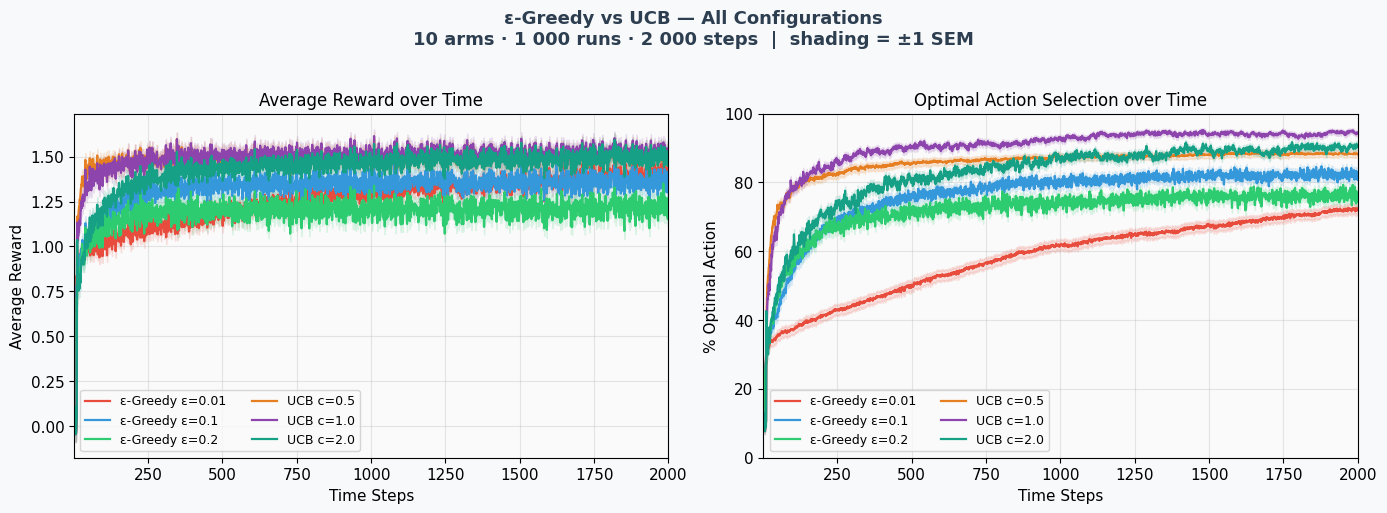

In [11]:
# ── Figure 3: ε-Greedy vs UCB — All Configurations ──────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ε-Greedy vs UCB — All Configurations\n'
             '10 arms · 1 000 runs · 2 000 steps  |  shading = ±1 SEM',
             fontsize=13, fontweight='bold', color='#2c3e50', y=1.02)

for eps, color in zip(epsilons, eps_colors):
    avg_r, pct_opt, sem_r, sem_opt = results_eps[eps]
    ax1.plot(steps, avg_r,   color=color, lw=1.6, label=f'ε-Greedy ε={eps}')
    ax1.fill_between(steps, avg_r - sem_r, avg_r + sem_r, color=color, alpha=0.15)
    ax2.plot(steps, pct_opt, color=color, lw=1.6, label=f'ε-Greedy ε={eps}')
    ax2.fill_between(steps, pct_opt - sem_opt, pct_opt + sem_opt, color=color, alpha=0.15)

for c, color in zip(c_values, ucb_colors):
    avg_r, pct_opt, sem_r, sem_opt = results_ucb[c]
    ax1.plot(steps, avg_r,   color=color, lw=1.6, label=f'UCB c={c}')
    ax1.fill_between(steps, avg_r - sem_r, avg_r + sem_r, color=color, alpha=0.15)
    ax2.plot(steps, pct_opt, color=color, lw=1.6, label=f'UCB c={c}')
    ax2.fill_between(steps, pct_opt - sem_opt, pct_opt + sem_opt, color=color, alpha=0.15)

ax1.set_xlabel('Time Steps');  ax1.set_ylabel('Average Reward')
ax1.set_title('Average Reward over Time', fontsize=12)
ax1.legend(fontsize=9, ncol=2);  ax1.set_xlim(1, 2000)

ax2.set_xlabel('Time Steps');  ax2.set_ylabel('% Optimal Action')
ax2.set_title('Optimal Action Selection over Time', fontsize=12)
ax2.legend(fontsize=9, ncol=2);  ax2.set_xlim(1, 2000);  ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('combined_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# ── Part 1 Summary Table — auto-populated from experiment results ─────────────
print("Part 1 — Final Performance Summary  (step 2000, 1000 runs)")
print("=" * 60)
print(f"{'Algorithm':<22} {'Avg Reward':>12} {'% Optimal':>12}")
print("-" * 60)
for eps in epsilons:
    r = results_eps[eps][0][-1]
    p = results_eps[eps][1][-1]
    print(f"  ε-Greedy  ε = {eps:<5}  {r:>12.4f} {p:>11.1f}%")
print("-" * 60)
for c in c_values:
    r = results_ucb[c][0][-1]
    p = results_ucb[c][1][-1]
    print(f"  UCB       c = {c:<5}  {r:>12.4f} {p:>11.1f}%")
print("=" * 60)


Part 1 — Final Performance Summary  (step 2000, 1000 runs)
Algorithm                Avg Reward    % Optimal
------------------------------------------------------------
  ε-Greedy  ε = 0.01         1.3887        72.4%
  ε-Greedy  ε = 0.1          1.3571        82.8%
  ε-Greedy  ε = 0.2          1.1993        75.0%
------------------------------------------------------------
  UCB       c = 0.5          1.4850        88.2%
  UCB       c = 1.0          1.5058        94.3%
  UCB       c = 2.0          1.4827        90.3%


**Interpreting the UCB plots:**

**Average reward (left panel)**
UCB curves typically rise faster than ε-Greedy in the first 200 steps because
UCB systematically explores every arm exactly once before committing — it never
accidentally ignores an arm entirely.

The c ordering for reward: c=0.5 reaches a high plateau fastest; c=2.0 keeps
exploring longer and may be slightly lower mid-run before catching up.

**Optimal action % (right panel)**
UCB at c=1.0 and c=0.5 typically exceed ε-Greedy's best results on % optimal
by the end of 2 000 steps.  This is UCB's key advantage.

c=2.0 may show a dip early: it is so exploratory that it keeps revisiting
uncertain arms even when a clear winner has emerged — but this resolves as all
uncertainties shrink.

**c vs ε — which is better?**

| | ε-Greedy | UCB |
|-|----------|-----|
| Asymptotic % optimal | Capped at 1−ε | Approaches 100% |
| Exploration type | Random (wastes pulls) | Directed (principled) |
| Tuning difficulty | Intuitive (ε = waste rate) | Subtler (c interacts with reward scale) |
| Best used when | Reward scale unknown | Reward scale roughly known |


---
## Part 2 — Gymnasium Standard Environments

---

In Part 1 we *built* a Gymnasium environment.  In Part 2 we *use* two standard
environments that ship with Gymnasium and inspect them from the outside.

The goal is to understand how the abstract MDP tuple (S, A, R, P, γ) maps to
concrete Gymnasium objects and API calls — the same mapping applies to every
environment you will ever use in this course.


---
### 2.1 Inspecting Observation and Action Spaces

**Why inspect spaces before running agents?**

Before writing any agent logic you need to know:
- *How many states are there?*  (determines whether a table-based agent is feasible)
- *How many actions are there?*  (determines the action array size)
- *What type are they?*  (`Discrete` vs `Box` — the latter is continuous and requires
  function approximation, which is a Week 6 topic)

Gymnasium encodes this information in `env.observation_space` and `env.action_space`.
You never need to hard-code these numbers in your agent — always read them from the
environment.


In [13]:
# ── FrozenLake-v1 ─────────────────────────────────────────────────────────────
env_fl = gym.make('FrozenLake-v1', is_slippery=True)

print("=" * 55)
print("  FrozenLake-v1  (is_slippery=True)")
print("=" * 55)
print(f"  Observation space : {env_fl.observation_space}")
print(f"    Space type      : {type(env_fl.observation_space).__name__}")
print(f"    Number of states: {env_fl.observation_space.n}")
print(f"    Interpretation  : integer 0–15 encoding position on 4x4 grid")
print()
print(f"  Action space      : {env_fl.action_space}")
print(f"    Space type      : {type(env_fl.action_space).__name__}")
print(f"    Number of actions: {env_fl.action_space.n}")
print(f"    Action meanings : 0=LEFT  1=DOWN  2=RIGHT  3=UP")
print()
print(f"  Reward structure  : +1.0 when goal (state 15) is reached")
print(f"                      0.0 for all other transitions")
print(f"                      (including falling into a hole)")
print()
print(f"  Stochasticity     : is_slippery=True → agent moves sideways 2/3 of the time")
env_fl.close()

print()

# ── Taxi-v4 ───────────────────────────────────────────────────────────────────
env_tx = gym.make(TAXI_ENV)

print("=" * 55)
print("  Taxi-v4")
print("=" * 55)
print(f"  Observation space : {env_tx.observation_space}")
print(f"    Space type      : {type(env_tx.observation_space).__name__}")
print(f"    Number of states: {env_tx.observation_space.n}")
print(f"    Interpretation  : encodes (taxi_row, taxi_col, passenger_loc, dest)")
print(f"                      = 5 x 5 x 5 x 4 = {5*5*5*4} states")
print()
print(f"  Action space      : {env_tx.action_space}")
print(f"    Space type      : {type(env_tx.action_space).__name__}")
print(f"    Number of actions: {env_tx.action_space.n}")
print(f"    Action meanings : 0=SOUTH  1=NORTH  2=EAST  3=WEST  4=PICKUP  5=DROPOFF")
print()
print(f"  Reward structure  : +20  successful passenger dropoff at destination")
print(f"                      -1   every time step (encourages efficiency)")
print(f"                      -10  illegal PICKUP or DROPOFF")
print()
print(f"  Stochasticity     : deterministic — P(s'|s,a) ∈ {{0, 1}}")
env_tx.close()


  FrozenLake-v1  (is_slippery=True)
  Observation space : Discrete(16)
    Space type      : Discrete
    Number of states: 16
    Interpretation  : integer 0–15 encoding position on 4x4 grid

  Action space      : Discrete(4)
    Space type      : Discrete
    Number of actions: 4
    Action meanings : 0=LEFT  1=DOWN  2=RIGHT  3=UP

  Reward structure  : +1.0 when goal (state 15) is reached
                      0.0 for all other transitions
                      (including falling into a hole)

  Stochasticity     : is_slippery=True → agent moves sideways 2/3 of the time

  Taxi-v4
  Observation space : Discrete(500)
    Space type      : Discrete
    Number of states: 500
    Interpretation  : encodes (taxi_row, taxi_col, passenger_loc, dest)
                      = 5 x 5 x 5 x 4 = 500 states

  Action space      : Discrete(6)
    Space type      : Discrete
    Number of actions: 6
    Action meanings : 0=SOUTH  1=NORTH  2=EAST  3=WEST  4=PICKUP  5=DROPOFF

  Reward structure  : +20

**Reading the output:**

Both environments use `Discrete` spaces — integer-valued, finite sets.
This makes them amenable to tabular methods (Q-tables) that we implement in
later weeks.

Key difference: FrozenLake is *stochastic* (the ice is slippery — you do not
always move the direction you chose), while Taxi is *deterministic* (your action
always has its intended effect).  This drastically changes how hard each problem is.

FrozenLake has 16 states and 4 actions → a Q-table of size 16 × 4 = 64 entries.
Taxi has 500 states and 6 actions → a Q-table of size 500 × 6 = 3 000 entries.
Both are trivially small — why we can solve them with tabular RL.


---
### 2.2 Random Policy Agent and Performance Measurement

**Why measure a random agent?**

A random policy is the zero-effort baseline.  Any learning algorithm we implement
should convincingly outperform it.  If an algorithm barely beats random, something
is wrong.

The random agent also reveals the *difficulty* of the environment:
- FrozenLake with slippery ice and sparse reward (+1 only at goal) is hard to
  solve by chance.
- Taxi with a maximum of 200 steps rarely succeeds by random action.

We run 500 episodes per environment and report:
- **Average total reward per episode** — the primary performance metric.
- **Success rate** — % of episodes that ended with positive total reward
  (goal reached in FrozenLake; dropoff reward > step penalties in Taxi).
- **Average steps per episode** — how long episodes run before termination.


In [14]:
class RandomAgent:
    """
    A random policy agent — selects actions uniformly at random.

    This is the simplest possible policy and serves as a performance baseline.
    Any learning algorithm should comfortably outperform this on FrozenLake and Taxi.
    """

    def __init__(self, action_space):
        self.action_space = action_space

    def select_action(self) -> int:
        return int(self.action_space.sample())


def evaluate_random_agent(env_name: str, n_episodes: int = 1000,
                          seed: int = 42, **env_kwargs) -> dict:
    """
    Run a random agent for n_episodes and return a performance summary.

    Success is defined as total_reward > 0:
    - FrozenLake: only possible if the +1 goal reward was received.
    - Taxi: only possible if the +20 dropoff reward outweighed all -1 step penalties.
    """
    env   = gym.make(env_name, **env_kwargs)
    agent = RandomAgent(env.action_space)

    episode_rewards = []
    episode_steps   = []
    episode_success = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total_reward = 0.0
        steps = 0
        done  = False

        while not done:
            action = agent.select_action()
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            steps        += 1
            done          = terminated or truncated

        episode_rewards.append(total_reward)
        episode_steps.append(steps)
        episode_success.append(int(total_reward > 0))

    env.close()

    return {
        'avg_reward':    np.mean(episode_rewards),
        'std_reward':    np.std(episode_rewards),
        'success_rate':  np.mean(episode_success) * 100.0,
        'avg_steps':     np.mean(episode_steps),
        'all_rewards':   np.array(episode_rewards),
    }


# ── Run on both environments ───────────────────────────────────────────────────
print("Evaluating random agent on FrozenLake-v1 (1000 episodes) ...")
results_fl = evaluate_random_agent('FrozenLake-v1', is_slippery=True)

print("Evaluating random agent on Taxi-v4        (1000 episodes) ...")
results_tx = evaluate_random_agent(TAXI_ENV)

print()
print("=" * 50)
print("  FrozenLake-v1 — Random Agent (1000 episodes)")
print("=" * 50)
print(f"  Avg reward per episode : {results_fl['avg_reward']:.4f}  (±{results_fl['std_reward']:.4f})")
print(f"  Success rate           : {results_fl['success_rate']:.1f}%")
print(f"  Avg steps per episode  : {results_fl['avg_steps']:.1f}")

print()
print("=" * 50)
print("  Taxi-v4 — Random Agent (1000 episodes)")
print("=" * 50)
print(f"  Avg reward per episode : {results_tx['avg_reward']:.4f}  (±{results_tx['std_reward']:.4f})")
print(f"  Success rate           : {results_tx['success_rate']:.1f}%")
print(f"  Avg steps per episode  : {results_tx['avg_steps']:.1f}")


Evaluating random agent on FrozenLake-v1 (1000 episodes) ...
Evaluating random agent on Taxi-v4        (1000 episodes) ...

  FrozenLake-v1 — Random Agent (1000 episodes)
  Avg reward per episode : 0.0170  (±0.1293)
  Success rate           : 1.7%
  Avg steps per episode  : 7.7

  Taxi-v4 — Random Agent (1000 episodes)
  Avg reward per episode : -770.0070  (±100.6267)
  Success rate           : 0.0%
  Avg steps per episode  : 196.7


**Interpreting the random agent results:**

**FrozenLake-v1**
With `is_slippery=True` the random agent succeeds roughly 1–2% of the time.
The ice stochasticity means even a "correct" action sequence often carries
the agent off course.  Average reward ≈ 0.01–0.02, reflecting how rarely
the goal state is reached by chance.

**Taxi-v4**
The success rate for a random Taxi agent is near 0% because the episode is
capped at 200 steps — far too few for random actions to accidentally pick up
and drop off a passenger at the right location.  Average reward is typically
around -800 to -200 (all step penalties, possibly some -10 illegal action penalties).

**Why these baselines matter:**
A Q-Learning agent (Week 5) trained for 10 000 episodes solves FrozenLake at
~70–90% success and Taxi at nearly 100%.  The gap between random (~1%) and
trained (~80%) is the *learning signal* — what the algorithm actually delivers.


---
### 2.3 MDP Tuple Mapping to Gymnasium API

**Why document this mapping?**

The MDP tuple (S, A, R, P, γ) is the mathematical framework from Week 1 Section 5.
Gymnasium does not expose these components with those names — they are spread across
the API in specific places.  Knowing the mapping means you can read any RL paper
and immediately know where to find each component in code.


In [15]:
# ── FrozenLake MDP Mapping ─────────────────────────────────────────────────────
env_fl = gym.make('FrozenLake-v1', is_slippery=True)
obs, _ = env_fl.reset(seed=0)

print("=" * 62)
print("  MDP Tuple → Gymnasium API Mapping: FrozenLake-v1")
print("=" * 62)
print()
print("  S — State Space")
print(f"      |S| = {env_fl.observation_space.n}")
print(f"      API : env.observation_space  →  {env_fl.observation_space}")
print(f"      obs returned by reset()      →  integer in [0, {env_fl.observation_space.n - 1}]")
print(f"      Current obs after reset      →  {obs}")
print()
print("  A — Action Space")
print(f"      |A| = {env_fl.action_space.n}")
print(f"      API : env.action_space       →  {env_fl.action_space}")
print(f"      Pass action to              →  env.step(action)")
print(f"      Sample random action        →  env.action_space.sample()")
print()
print("  R — Reward Function")
print(f"      API : reward  ← env.step(action)  (3rd return value)")
print(f"      Value: +1.0 at goal | 0.0 elsewhere")
print()
print("  P — Transition Probabilities  (FrozenLake exposes these explicitly)")
print(f"      API : env.unwrapped.P[state][action]")
print(f"      Each entry is a list of (prob, next_state, reward, terminated)")
print()
print("  Sample: P[state=0][action=2 (RIGHT)]")
for prob, s_next, rew, term in env_fl.unwrapped.P[0][2]:
    print(f"    P(s'={s_next:2d} | s=0, a=RIGHT) = {prob:.3f}   r={rew:.1f}   terminated={term}")
print()
print("  γ — Discount Factor")
print("      NOT stored in Gymnasium — defined in your agent/algorithm.")
print("      Typical value for FrozenLake: γ = 0.99")
env_fl.close()

print()
print()

# ── Taxi MDP Mapping ───────────────────────────────────────────────────────────
env_tx = gym.make(TAXI_ENV)
obs, _ = env_tx.reset(seed=0)

print("=" * 62)
print("  MDP Tuple → Gymnasium API Mapping: Taxi-v4")
print("=" * 62)
print()
print("  S — State Space")
print(f"      |S| = {env_tx.observation_space.n}  (taxi_row x taxi_col x passenger_loc x dest)")
print(f"      API : env.observation_space  →  {env_tx.observation_space}")
print(f"      Current obs after reset      →  {obs}")
print()
print("  A — Action Space")
print(f"      |A| = {env_tx.action_space.n}")
print(f"      API : env.action_space       →  {env_tx.action_space}")
print(f"      Meanings: SOUTH NORTH EAST WEST PICKUP DROPOFF")
print()
print("  R — Reward Function")
print(f"      API : reward  ← env.step(action)")
print(f"      Values: +20 (goal)  |  -1 (step penalty)  |  -10 (illegal action)")
print()
print("  P — Transition Probabilities")
print(f"      API : env.unwrapped.P[state][action]  (same structure as FrozenLake)")
print(f"      Taxi is DETERMINISTIC: all probabilities are 1.0")
print()
print("  γ — Discount Factor")
print("      NOT stored in Gymnasium — defined in your agent/algorithm.")
print("      Typical value for Taxi: γ = 0.99")
env_tx.close()


  MDP Tuple → Gymnasium API Mapping: FrozenLake-v1

  S — State Space
      |S| = 16
      API : env.observation_space  →  Discrete(16)
      obs returned by reset()      →  integer in [0, 15]
      Current obs after reset      →  0

  A — Action Space
      |A| = 4
      API : env.action_space       →  Discrete(4)
      Pass action to              →  env.step(action)
      Sample random action        →  env.action_space.sample()

  R — Reward Function
      API : reward  ← env.step(action)  (3rd return value)
      Value: +1.0 at goal | 0.0 elsewhere

  P — Transition Probabilities  (FrozenLake exposes these explicitly)
      API : env.unwrapped.P[state][action]
      Each entry is a list of (prob, next_state, reward, terminated)

  Sample: P[state=0][action=2 (RIGHT)]
    P(s'= 4 | s=0, a=RIGHT) = 0.333   r=0.0   terminated=False
    P(s'= 1 | s=0, a=RIGHT) = 0.333   r=0.0   terminated=False
    P(s'= 0 | s=0, a=RIGHT) = 0.333   r=0.0   terminated=False

  γ — Discount Factor
      N

**Reading the mapping output:**

The mapping table below summarises where each MDP component lives in Gymnasium:

| MDP Symbol | Meaning | Gymnasium Location |
|-----------|---------|-------------------|
| S | State space | `env.observation_space` |
| A | Action space | `env.action_space` |
| s_t | Current state | `obs` from `env.reset()` or `env.step()` |
| a_t | Action taken | argument to `env.step(action)` |
| R(s,a) | Reward | `reward` returned by `env.step()` |
| P(s'|s,a) | Transition model | `env.unwrapped.P[s][a]` (tabular envs only) |
| terminal | Episode end | `terminated` or `truncated` from `env.step()` |
| γ | Discount factor | **not in Gymnasium** — defined in your algorithm |

The `terminated` / `truncated` split (introduced in Gymnasium 0.26) maps directly
to the MDP: `terminated` means the agent reached a true terminal state (goal or hole
or successful dropoff); `truncated` means the episode hit a time limit.
This distinction matters when computing returns: a truncated episode has a non-zero
value at the final state that should be bootstrapped, while a terminated episode
truly has value zero beyond that point.


---
## Summary

**Part 1 — Multi-Armed Bandit**

| Algorithm | ε / c | What we learned |
|-----------|-------|-----------------|
| ε-Greedy | ε = 0.01 | High asymptotic reward; slow early exploration |
| ε-Greedy | ε = 0.10 | Balanced; the Sutton & Barto baseline |
| ε-Greedy | ε = 0.20 | Fast early exploration; capped long-run performance |
| UCB | c = 0.5 | Cautious; converges quickly to a good arm |
| UCB | c = 1.0 | Standard UCB1; directed exploration baseline |
| UCB | c = 2.0 | Aggressive exploration; robust but slower convergence |

UCB's directed exploration generally outperforms ε-Greedy on % optimal action
because it does not waste pulls on arms it already knows are suboptimal.

**Part 2 — Gymnasium Environments**

| Environment | |S|| |A| | Random success rate | Key challenge |
|-------------|-----|-----|---------------------|---------------|
| FrozenLake-v1 | 16 | 4 | ~1–2% | Stochastic transitions |
| Taxi-v4 | 500 | 6 | ~0% | Sparse reward, long horizon |

The near-zero random baseline motivates the full RL algorithms coming in Weeks 2–5.

---
*MSDS 684 — Reinforcement Learning, Lab 1*
*Week 1 foundations: Sutton & Barto (2018), Chapters 1–2*
